### Import datas

In [33]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)
print("Fichiers dans le dossier :")
print(os.listdir(path))

Path to dataset files: C:\Users\dav-9\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2
Fichiers dans le dossier :
['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


### Read in pandas

In [40]:
import pandas as pd

file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# Vérifier les colonnes
print(credits.columns)
print(movies.columns)

# Faire la jointure sur movie_id (credits) et id (movies)
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

print(data.shape)
col = data.columns.tolist()
for i in range(0, len(col), 5) :
    if (i + 5 <= len(col)) :
        print(col[i : i + 5])
    else :
        print(col[i:])
print(data.head())

Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')
Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')
(4803, 24)
['budget', 'genres', 'homepage', 'id', 'keywords']
['original_language', 'original_title', 'overview', 'popularity', 'production_companies']
['production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages']
['status', 'tagline', 'title_x', 'vote_average', 'vote_count']
['movie_id', 'title_y', 'cast', 'crew']
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam.

In [ ]:
import json
import networkx as nx
# get first 3 actors from json 
def get_top3_actors(cast_json) :
    try :
        cast_list = json.loads(cast_json)  # convertir la chaîne JSON en liste
        # récupérer les 3 premiers noms, remplir avec None si moins de 3 acteurs
        top3 = [actor['name'] for actor in cast_list[:3]]
        #print(top3)
        while len(top3) < 3 :
            top3.append(None)
        return top3
    except :
        return [None, None, None]

def get_imdb_graph(data, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()
    
    # Filtre par genre
    if genre is not None :
        df = df[df['genres'].str.contains(genre, na=False)]
    

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]
    
    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    #print(df.shape)
    # Garder seulement les lignes où 'cast' contient au moins 3 acteurs
    df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= 3)]

    #print(df.shape)

    # Appliquer la fonction à la colonne 'cast' et créer 3 nouvelles colonnes
    df[['actor1', 'actor2', 'actor3']] = pd.DataFrame(df['cast'].apply(get_top3_actors).tolist(), index=df.index)
    
    #print(df.columns.tolist())
    #print(df.head())
    
    # Création du graphe
    G = nx.Graph()
    
    for _, row in df.iterrows():
        actors = [row['actor1'],
                    row['actor2'],
                    row['actor3']]
        
        # Retirer valeurs nulles
        actors = [a for a in actors if pd.notna(a)]
        
        # Ajouter toutes les combinaisons d'acteurs
        for i in range(len(actors)) :
            for j in range(i+1, len(actors)) :
                G.add_edge(actors[i], actors[j])
    
    return G

In [110]:
G = get_imdb_graph(data, firstyear=1990, lastyear=2009)

print("Nombre d'acteurs (noeuds) :", G.number_of_nodes())
print("Nombre de collaborations (arêtes) :", G.number_of_edges())

(2826, 3)
(2795, 3)
Nombre d'acteurs (noeuds) : 3449
Nombre de collaborations (arêtes) : 8113


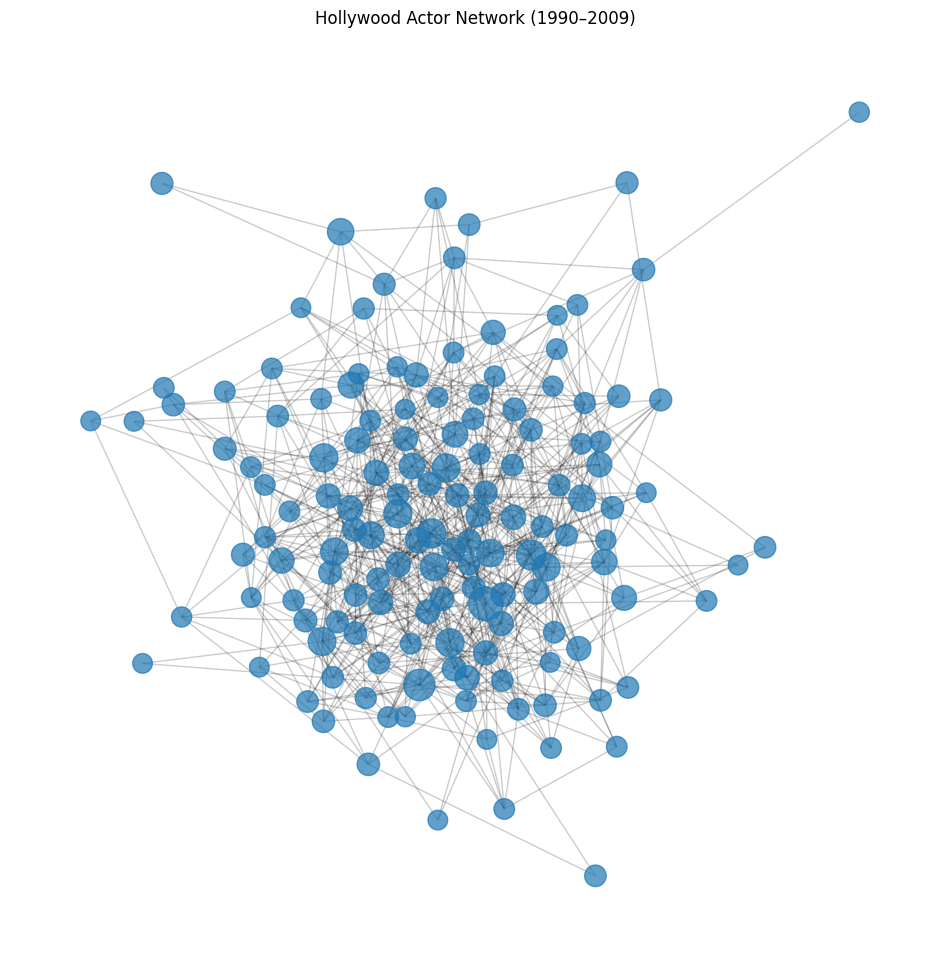

In [111]:
import matplotlib.pyplot as plt

# Calcul du degré (nombre de connexions)
degree_dict = dict(G.degree())

# Garder les acteurs avec au moins 20 connexions
filtered_nodes = [node for node, deg in degree_dict.items() if deg >= 20]

subG = G.subgraph(filtered_nodes)

plt.figure(figsize=(12,12))
pos = nx.spring_layout(subG, k=0.3)

nx.draw_networkx_nodes(subG, pos, 
                       node_size=[degree_dict[n]*10 for n in subG.nodes()],
                       alpha=0.7)

nx.draw_networkx_edges(subG, pos, alpha=0.2)

plt.title("Hollywood Actor Network (1990–2009)")
plt.axis("off")
plt.show()